Question 2. Surrogate model training

Loading the filtered dataset from Question 1.

In [31]:
import numpy as np
from pathlib import Path

DATA_FILE = Path("./plate_clean_13x13_.npz")
if not DATA_FILE.exists():
    raise FileNotFoundError("Filtered dataset not found. Run Q1 first to generate 'plate_clean_13x13_.npz'.")

d = np.load(DATA_FILE, allow_pickle=True)
X = d["X"]
Y = d["Y"]
meta = d.get("meta", None)
print(f"Loaded filtered dataset: {DATA_FILE}")
print(f"Shapes: X={X.shape}, Y={Y.shape}")


Loaded filtered dataset: plate_clean_13x13_.npz
Shapes: X=(1780, 169), Y=(1780, 169)


Peparing and Normalising the dataset.

In [32]:
# Process and reshape data for CNN 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
#shape
rows, cols = 13, 13

# Flatten for scaling
X_flat = X.reshape(X.shape[0], -1)
Y_flat = Y.reshape(Y.shape[0], -1)

# Normalise data
scaler_X = StandardScaler().fit(X_flat)
scaler_Y = StandardScaler().fit(Y_flat)
X_scaled = scaler_X.transform(X_flat)
Y_scaled = scaler_Y.transform(Y_flat)

# Reshape to CNN format
X_scaled = X_scaled.reshape(-1, rows, cols, 1)
Y_scaled = Y_scaled.reshape(-1, rows, cols, 1)

# Split into train/validation/test
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_scaled, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print("Final shapes ->")
print("Train:", X_train.shape, Y_train.shape)
print("Val:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)


Final shapes ->
Train: (1246, 13, 13, 1) (1246, 13, 13, 1)
Val: (267, 13, 13, 1) (267, 13, 13, 1)
Test: (267, 13, 13, 1) (267, 13, 13, 1)


Curve fitting

~~~~ K-Fold Cross-Validation Results~~~~
deg=1  | mean RMSE=45.617 ±2.513 | mean R²=0.0290
deg=2  | mean RMSE=45.606 ±2.399 | mean R²=0.0292
deg=3  | mean RMSE=45.617 ±2.400 | mean R²=0.0287
deg=5  | mean RMSE=45.652 ±2.416 | mean R²=0.0272
deg=7  | mean RMSE=45.641 ±2.194 | mean R²=0.0271
deg=9  | mean RMSE=45.911 ±2.361 | mean R²=0.0160

Chosen polynomial degree based on K-Fold RMSE: 2


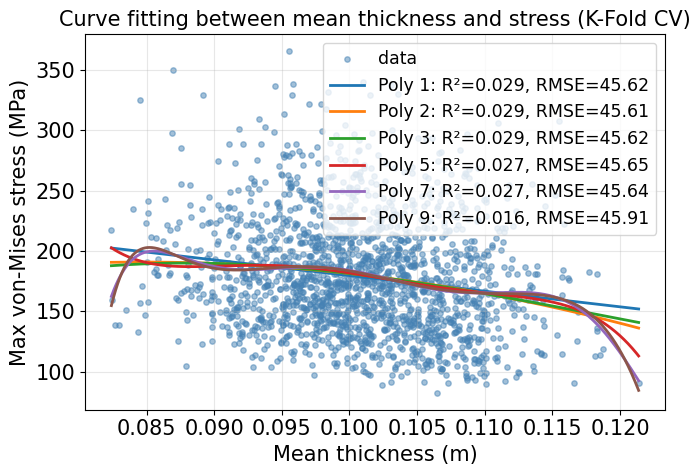

In [33]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

t_mean = X.mean(axis=1)
s_max = Y.max(axis=1)

degrees = [1, 2, 3, 5, 7, 9]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_rmse, val_r2 = [], []

print("~~~~ K-Fold Cross-Validation Results~~~~")
for deg in degrees:
    rmse_fold, r2_fold = [], []
    for train_idx, val_idx in kf.split(t_mean):
        X_tr, X_v = t_mean[train_idx], t_mean[val_idx]
        Y_tr, Y_v = s_max[train_idx], s_max[val_idx]
        coef = np.polyfit(X_tr, Y_tr, deg)
        Y_pred = np.polyval(coef, X_v)
        rmse = np.sqrt(mean_squared_error(Y_v, Y_pred))
        r2 = r2_score(Y_v, Y_pred)
        rmse_fold.append(rmse)
        r2_fold.append(r2)
    val_rmse.append(np.mean(rmse_fold))
    val_r2.append(np.mean(r2_fold))
    print(f"deg={deg:<2d} | mean RMSE={np.mean(rmse_fold):.3f} ±{np.std(rmse_fold):.3f} | mean R²={np.mean(r2_fold):.4f}")

best_idx = np.argmin(val_rmse)
best_deg = degrees[best_idx]
print(f"\nChosen polynomial degree based on K-Fold RMSE: {best_deg}")

coef_best = np.polyfit(t_mean, s_max, best_deg)
s_pred_best = np.polyval(coef_best, t_mean)

X_smooth = np.linspace(t_mean.min(), t_mean.max(), 1000)
plt.figure(figsize=(7,5))
plt.scatter(t_mean, s_max, color='steelblue', s=15, alpha=0.5, label='data')
for i, deg in enumerate(degrees):
    coef = np.polyfit(t_mean, s_max, deg)
    Y_poly = np.polyval(coef, X_smooth)
    plt.plot(X_smooth, Y_poly, lw=2, label=f'Poly {deg}: R²={val_r2[i]:.3f}, RMSE={val_rmse[i]:.2f}')
plt.xlabel("Mean thickness (m)")
plt.ylabel("Max von-Mises stress (MPa)")
plt.title("Curve fitting between mean thickness and stress (K-Fold CV)")
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CNN Surrogate

In [34]:
# --- Build and train CNN surrogate model ---
from tensorflow.keras import models, layers, callbacks, optimizers

def build_cnn_model():
    model = models.Sequential(name="CNN_Surrogate")

    # convolution and pooling layers
    model.add(layers.Input(shape=(rows, cols, 1)))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # flatten and dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.15))
    model.add(layers.Dense(rows * cols, activation='linear'))
    model.add(layers.Reshape((rows, cols, 1)))

    # compile model
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='mse',
                  metrics=['mae', 'mape'])
    return model

# create model
model = build_cnn_model()
model.summary()

# callbacks to stop early and reduce learning rate
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

# train model
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Model: "CNN_Surrogate"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 169)            │        21,801 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 13, 13, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,473 (447.16 KB)

 Trainable params: 114,473 (447.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.7988 - mae: 0.7036 - mape: 277.5319 - val_loss: 0.5617 - val_mae: 0.5826 - val_mape: 2401.4768 - learning_rate: 0.0010
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5186 - mae: 0.5579 - mape: 516.3503 - val_loss: 0.4093 - val_mae: 0.4871 - val_mape: 2887.7710 - learning_rate: 0.0010
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.4080 - mae: 0.4925 - mape: 655.2696 - val_loss: 0.3256 - val_mae: 0.4355 - val_mape: 6188.4912 - learning_rate: 0.0010
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3497 - mae: 0.4546 - mape: 588.4687 - val_loss: 0.2872 - val_mae: 0.4032 - val_mape: 2475.3135 - learning_rate: 0.0010
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.3053 - mae: 0.4249 - mape: 851.8815 - val_loss: 0.2467 - val_mae: 0.3772 - val_mape: 4195.7466 - learning_rate: 0.0010
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2805 - mae: 0.4068 - mape: 805.86

Training history Plot

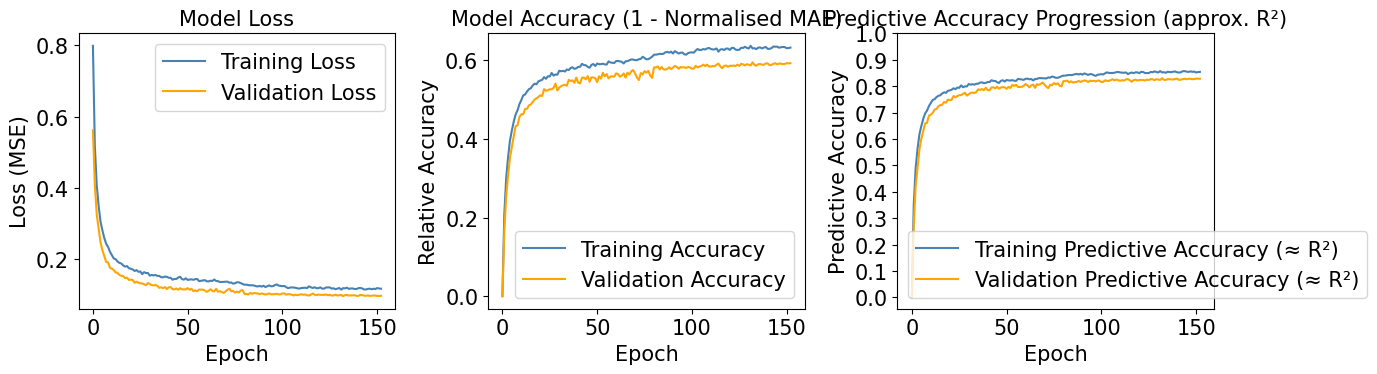

In [35]:
# --- Plot training history and predictive accuracy ---
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

# loss (MSE)
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# accuracy (1 - normalised MAE)
train_mae = np.array(history.history['mae'])
val_mae = np.array(history.history['val_mae'])
train_acc = 1 - train_mae / np.max(train_mae)
val_acc = 1 - val_mae / np.max(val_mae)

plt.subplot(1,3,2)
plt.plot(train_acc, label='Training Accuracy', color='steelblue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.title('Model Accuracy (1 - Normalised MAE)')
plt.xlabel('Epoch')
plt.ylabel('Relative Accuracy')
plt.legend()

# predictive accuracy (approx R² progression)
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
train_r2 = 1 - train_loss / np.max(train_loss)
val_r2 = 1 - val_loss / np.max(val_loss)

plt.subplot(1,3,3)
plt.plot(train_r2, label='Training Predictive Accuracy (≈ R²)', color='steelblue')
plt.plot(val_r2, label='Validation Predictive Accuracy (≈ R²)', color='orange')
plt.title('Predictive Accuracy Progression (approx. R²)')
plt.xlabel('Epoch')
plt.ylabel('Predictive Accuracy')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

plt.tight_layout()
plt.show()


Evaluation of predictions

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Test Results:
MSE = 79.26 MPa²
MAE = 6.11 MPa
R² = 0.930


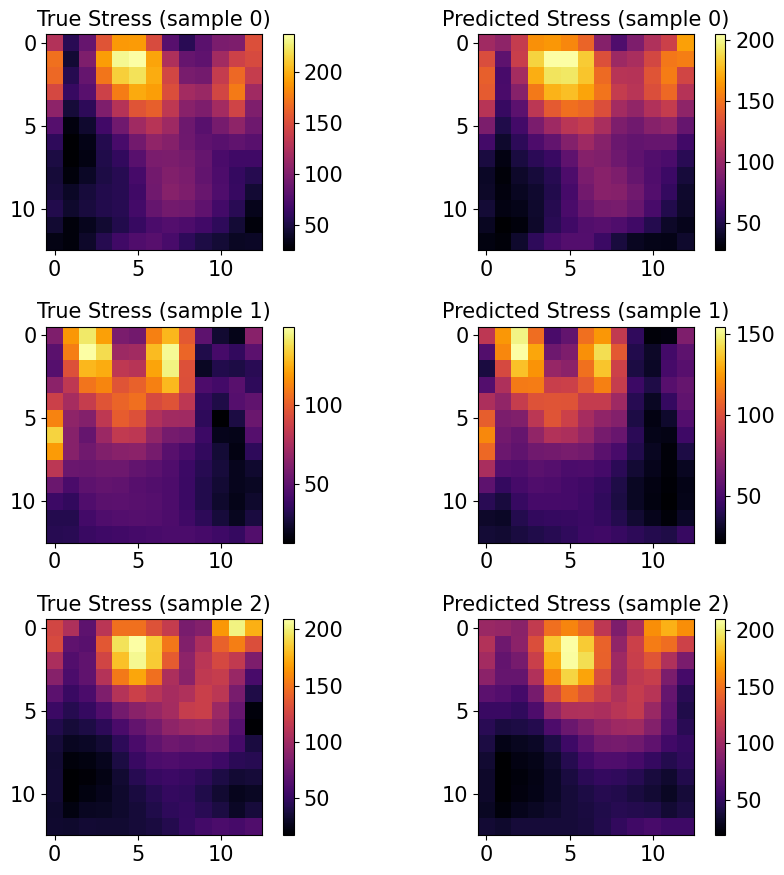

In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Y_pred = model.predict(X_test)

# Convert back to real (unscaled) MPa
Y_pred_inv = scaler_Y.inverse_transform(Y_pred.reshape(len(Y_pred), -1)).reshape(-1, rows, cols)
Y_true_inv = scaler_Y.inverse_transform(Y_test.reshape(len(Y_test), -1)).reshape(-1, rows, cols)

mse_real = mean_squared_error(Y_true_inv.flatten(), Y_pred_inv.flatten())
mae_real = mean_absolute_error(Y_true_inv.flatten(), Y_pred_inv.flatten())
r2_real = r2_score(Y_true_inv.flatten(), Y_pred_inv.flatten())

print(f"Test Results:\nMSE = {mse_real:.2f} MPa²\nMAE = {mae_real:.2f} MPa\nR² = {r2_real:.3f}")

#Visualise 3 predictions vs true
n_show = 3
plt.figure(figsize=(9, 3 * n_show))
for i in range(n_show):
    plt.subplot(n_show, 2, 2*i+1)
    plt.imshow(Y_true_inv[i], cmap='inferno')
    plt.title(f"True Stress (sample {i})")
    plt.colorbar()
    plt.subplot(n_show, 2, 2*i+2)
    plt.imshow(Y_pred_inv[i], cmap='inferno')
    plt.title(f"Predicted Stress (sample {i})")
    plt.colorbar()
plt.tight_layout()
plt.show()

Robustness Check (Near Yield stress analysis)


Found 53 near-yield samples (19.85% of test set)

Performance on near-yield cases:
Yield-only MSE: 108.70
Yield-only MAE: 7.10



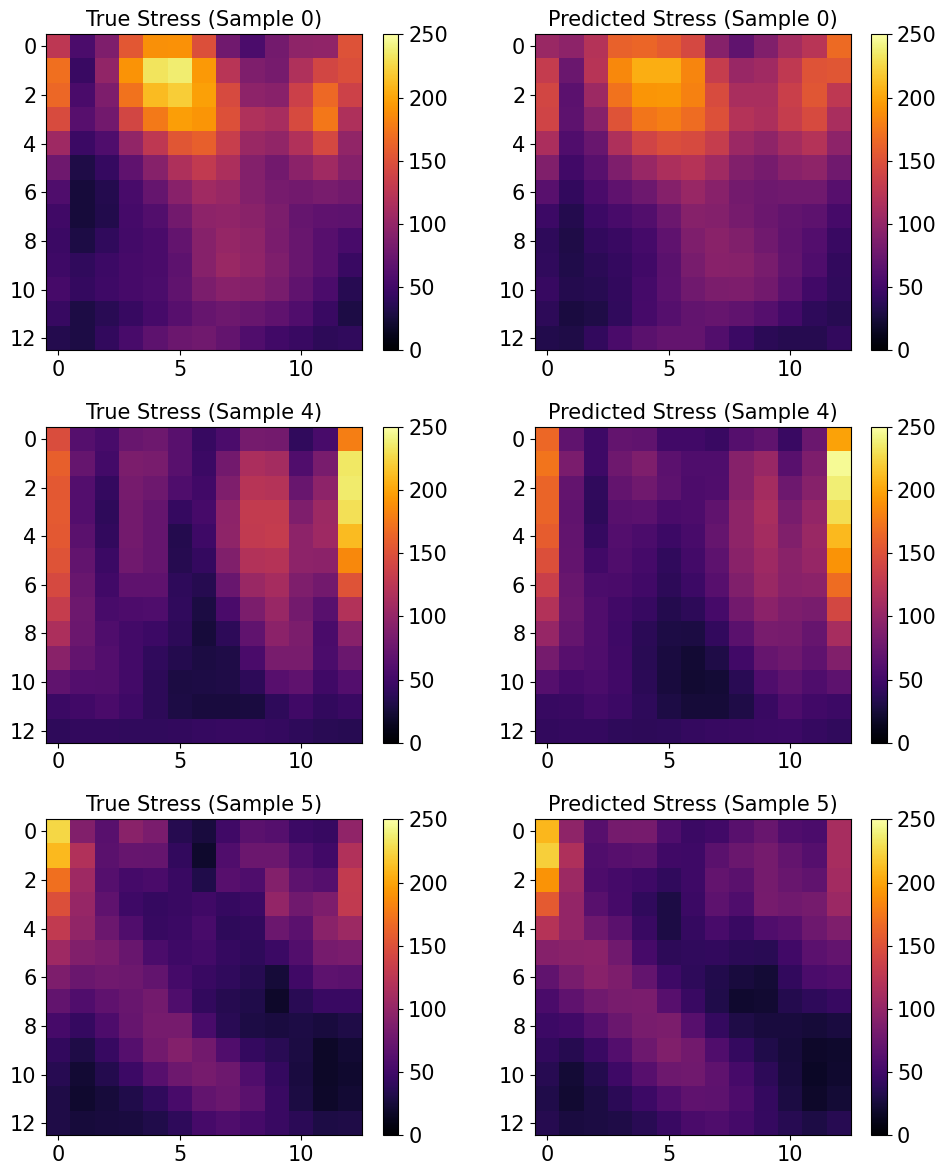

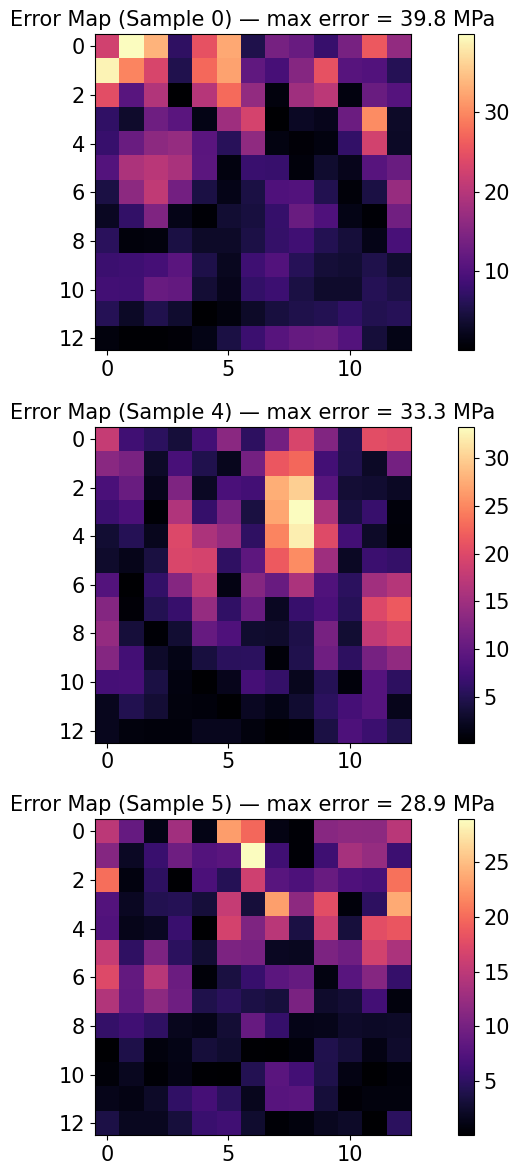

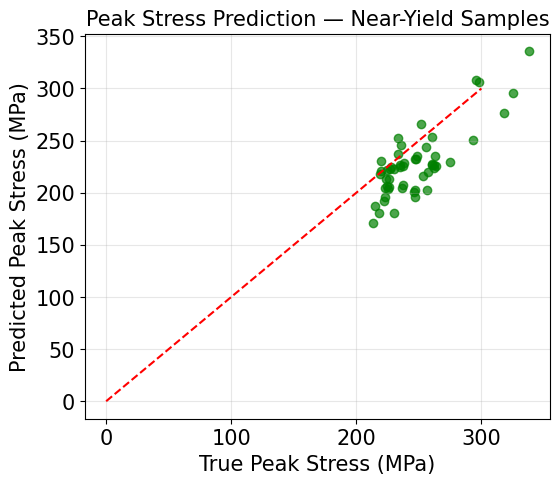

Bias in peak stress prediction: -19.91 MPa


In [37]:


yield_strength = 250  # MPa (from coursework spec)
threshold = 0.85 * yield_strength  # Define "near-yield"

# Max stress per sample
Y_true_max = Y_true_inv.reshape(len(Y_true_inv), -1).max(axis=1)

# Indices of samples with high stress
near_yield_idx = np.where(Y_true_max >= threshold)[0]
print(f"\nFound {len(near_yield_idx)} near-yield samples "
      f"({100*len(near_yield_idx)/len(Y_true_inv):.2f}% of test set)\n")

# Extract these samples
Y_true_yield = Y_true_inv[near_yield_idx]
Y_pred_yield = Y_pred_inv[near_yield_idx]

# Compute errors on high-stress samples
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_yield = mean_squared_error(Y_true_yield.flatten(), Y_pred_yield.flatten())
mae_yield = mean_absolute_error(Y_true_yield.flatten(), Y_pred_yield.flatten())

print("Performance on near-yield cases:")
print(f"Yield-only MSE: {mse_yield:.2f}")
print(f"Yield-only MAE: {mae_yield:.2f}\n")

# --- Visualise true vs predicted for near-yield samples ---
n_show = min(3, len(near_yield_idx))
plt.figure(figsize=(10, 4*n_show))

for i in range(n_show):
    idx = near_yield_idx[i]

    plt.subplot(n_show, 2, 2*i+1)
    plt.imshow(Y_true_inv[idx], cmap='inferno', vmin=0, vmax=yield_strength)
    plt.title(f"True Stress (Sample {idx})")
    plt.colorbar()

    plt.subplot(n_show, 2, 2*i+2)
    plt.imshow(Y_pred_inv[idx], cmap='inferno', vmin=0, vmax=yield_strength)
    plt.title(f"Predicted Stress (Sample {idx})")
    plt.colorbar()

plt.tight_layout()
plt.show()

# --- Error maps ---
plt.figure(figsize=(10, 4*n_show))
for i in range(n_show):
    idx = near_yield_idx[i]
    error_map = np.abs(Y_pred_inv[idx] - Y_true_inv[idx])

    plt.subplot(n_show, 1, i+1)
    plt.imshow(error_map, cmap='magma')
    plt.title(f"Error Map (Sample {idx}) — max error = {error_map.max():.1f} MPa")
    plt.colorbar()

plt.tight_layout()
plt.show()

# --- Peak stress prediction scatter plot ---
true_peaks = Y_true_yield.reshape(len(Y_true_yield), -1).max(axis=1)
pred_peaks = Y_pred_yield.reshape(len(Y_pred_yield), -1).max(axis=1)

plt.figure(figsize=(6,5))
plt.scatter(true_peaks, pred_peaks, alpha=0.7, color='green')
plt.plot([0, 300], [0, 300], 'r--')
plt.xlabel("True Peak Stress (MPa)")
plt.ylabel("Predicted Peak Stress (MPa)")
plt.title("Peak Stress Prediction — Near-Yield Samples")
plt.grid(True, alpha=0.3)
plt.show()

bias = np.mean(pred_peaks - true_peaks)
print(f"Bias in peak stress prediction: {bias:+.2f} MPa")



================ GLOBAL BIAS ANALYSIS ================

Global Peak Stress Bias: -10.66 MPa
Global Peak Stress MAE:  14.68 MPa



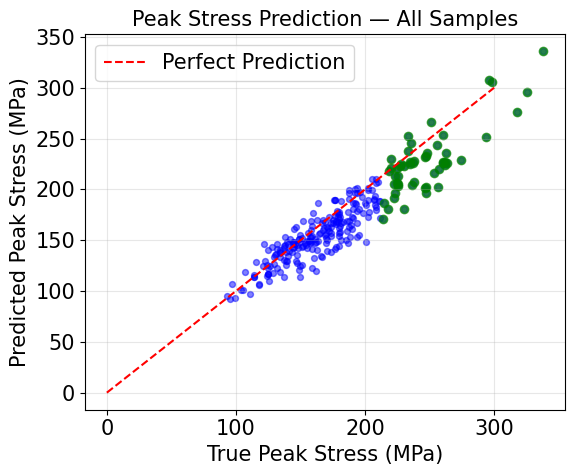

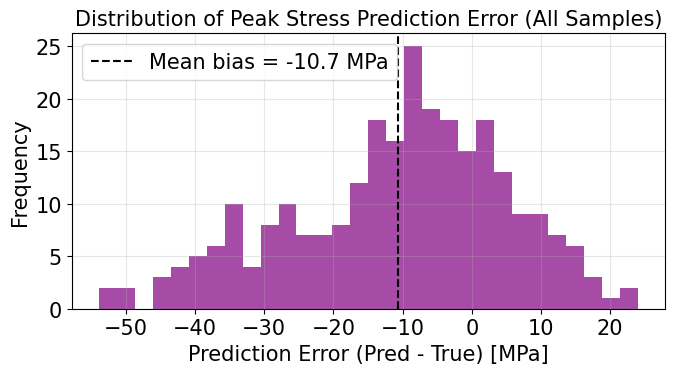

In [ ]:
# ============================================================
# GLOBAL BIAS ANALYSIS (ALL SAMPLES)
# ============================================================

print("\n================ GLOBAL BIAS ANALYSIS ================\n")
plt.rcParams.update({
    'font.size': 15,          # default text size
    'axes.titlesize': 15,     # title size
    'axes.labelsize': 15,     # x/y label size
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 15,    # legend text
    'figure.titlesize': 15    # figure title
})

# Peak stress for ALL samples
Y_true_all = Y_true_inv
Y_pred_all = Y_pred_inv

true_peaks_all = Y_true_all.reshape(len(Y_true_all), -1).max(axis=1)
pred_peaks_all = Y_pred_all.reshape(len(Y_pred_all), -1).max(axis=1)

# Compute global bias
global_bias = np.mean(pred_peaks_all - true_peaks_all)
global_mae = np.mean(np.abs(pred_peaks_all - true_peaks_all))

print(f"Global Peak Stress Bias: {global_bias:+.2f} MPa")
print(f"Global Peak Stress MAE:  {global_mae:.2f} MPa\n")

# ------------------------------------------------------------
# Scatter plot for ALL samples
# ------------------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(true_peaks_all, pred_peaks_all, alpha=0.5, color='blue', s=18)
plt.scatter(true_peaks, pred_peaks, alpha=0.7, color='green')
plt.plot([0, 300], [0, 300], 'r--', label='Perfect Prediction')
plt.xlabel("True Peak Stress (MPa)")
plt.ylabel("Predicted Peak Stress (MPa)")
plt.title("Peak Stress Prediction — All Samples")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------

Consistency check using K-Fold Validation

In [39]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score
import numpy as np

# --- K-Fold cross-validation ---
k = 3
kf = KFold(n_splits=k, shuffle=True, random_state=42)
r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\nFold {fold+1}/{k}")
    X_train, Y_train = X_scaled[train_idx], Y_scaled[train_idx]
    X_val,   Y_val   = X_scaled[val_idx],  Y_scaled[val_idx]

    model = build_cnn_model()
    model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=100, batch_size=16, verbose=0,
        callbacks=[early_stop]
    )

    Y_pred = model.predict(X_val)
    r2 = r2_score(Y_val.flatten(), Y_pred.flatten())
    r2_scores.append(r2)
    print(f"R² = {r2:.3f}")

print(f"\nMean R² across folds = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

# --- Hold-out validation (single split) ---
print("\n=== Hold-out validation (70/15/15 split) ===")

# Split data
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_scaled, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

model = build_cnn_model()
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=150, batch_size=16, verbose=1,
    callbacks=[early_stop]
)

# Evaluate on test data
Y_pred_test = model.predict(X_test)
r2_test = r2_score(Y_test.flatten(), Y_pred_test.flatten())
mse_test = np.mean((Y_test.flatten() - Y_pred_test.flatten())**2)
mae_test = np.mean(np.abs(Y_test.flatten() - Y_pred_test.flatten()))

print(f"\nHold-out Test Results:")
print(f"R² = {r2_test:.3f}")
print(f"MSE = {mse_test:.2f}")
print(f"MAE = {mae_test:.2f}")



Fold 1/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
R² = 0.418

Fold 2/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
R² = 0.423

Fold 3/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
R² = 0.405

Mean R² across folds = 0.415 ± 0.008

=== Hold-out validation (70/15/15 split) ===
Epoch 1/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.8112 - mae: 0.7078 - mape: 413.4419 - val_loss: 0.5667 - val_mae: 0.5819 - val_mape: 2229.2073
Epoch 2/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5190 - mae: 0.5567 - mape: 478.0115 - val_loss: 0.4087 - val_mae: 0.4917 - val_mape: 5564.3198
Epoch 3/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.4097 - mae: 0.4925 - mape: 605.5204 - val_loss: 0.3346 - val_mae: 0.4354 - val_mape: 5310.7905
Epoch 4/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.3489 - mae: 0.4530 - mape: 851.4408 - val_loss: 0.2785 - val_mae: 0.4009 - val_mape: 2292.4143
Epoch 5/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3089 - mae: 0.4264 - mape: 873.7838 - val_l

Optimisation using trust-region constrained method

| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |   4   |   0   | +1.5600e-04 | 1.00e+00 | 7.51e-03 | 8.36e-01 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |   8   |   1   | +1.5600e-04 | 1.00e-01 | 7.51e-03 | 8.36e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  12   |   3   | +3.1759e-04 | 2.00e-01 | 5.07e-03 | 8.89e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  16   |   4   | +6.5542e-04 | 3.20e-01 | 1.57e-02 | 7.63e-03 | 1.00e+00 |  1.00e-01   |   4   |
|   5   |  20   |   6   | +1.3324e-03 | 1.80e+00 | 2.94e-02 | 8.91e-03 | 1.00e+00 |  1.00e-01   |   4   |
|   6   |  24   |   8   | +2.0242e-03 | 1.10e+01 | 2.08e-02 | 3.40e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   7   |  28   |  10   | +2.0242e-03 | 1.10e+00 | 2.08e-02 | 3.40e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   8   |  32   |  11   | +2.0242e-03 | 1.10e-

c:\tfenv\lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  37   |  144  |  41   | +9.5154e-04 | 6.59e+01 | 1.68e-04 | 3.01e-02 | 1.00e+00 |  2.00e-02   |   0   |
|  38   |  148  |  43   | +8.5925e-04 | 6.59e+01 | 3.59e-05 | 1.46e-02 | 1.67e+00 |  2.00e-02   |   4   |
|  39   |  152  |  44   | +7.0053e-04 | 6.59e+01 | 4.43e-05 | 3.59e-03 | 2.95e+00 |  2.00e-02   |   4   |
|  40   |  156  |  45   | +6.6331e-04 | 6.59e+01 | 1.80e-05 | 3.57e-03 | 3.54e+00 |  2.00e-02   |   4   |
|  41   |  156  |  45   | +6.6331e-04 | 3.30e+02 | 4.38e-06 | 3.57e-03 | 1.00e+00 |  4.00e-03   |   0   |
|  42   |  160  |  46   | +6.6331e-04 | 3.30e+01 | 4.38e-06 | 3.57e-03 | 1.00e+00 |  4.00e-03   |   4   |
|  43   |  164  |  47   | +6.6331e-04 | 3.30e+00 | 4.38e-06 | 3.57e-03 | 1.00e+00 |  4.00e-03   |   4   |
|  44   |  168  |  48   | +6.6331e-04 | 1.35e+00 | 4.38e-06 | 3.57e-03 | 1.00e+00 |  4.00e-03   |   4   |
|  45   |  172  |  49   | +5.7975e-04 | 2.22e+00 | 2.96e-06 | 3.02e-03 | 1.46e+00 |  4.00e-03   |   4   |
|  46   |  176  |  50   | +5.7975e-04 | 2.22e-

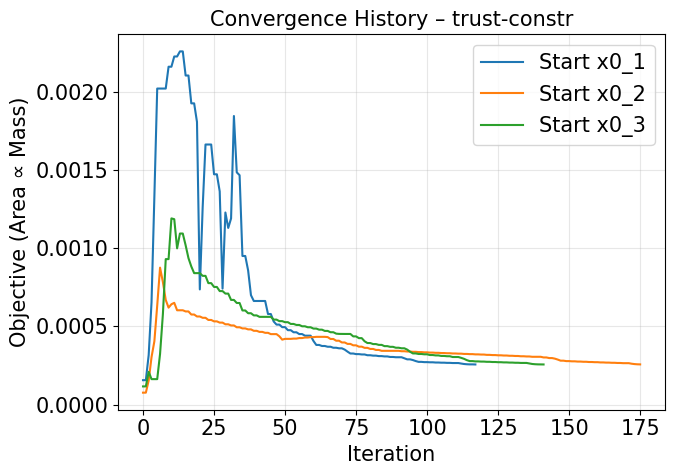

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds, NonlinearConstraint

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    'font.size': 15,          # default text size
    'axes.titlesize': 15,     # title size
    'axes.labelsize': 15,     # x/y label size
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 15,    # legend text
    'figure.titlesize': 15    # figure title
})

# ------------------------------------------------------------
#  Problem Data (from coursework)
# ------------------------------------------------------------
E = 70e9            # Pa
sigma_y = 250e6     # Pa
L = 1.0             # m
P = 1000.0          # N
delta_max = 0.07    # m
rho = 1.0           # density scale; mass ∝ A for fixed L

# ------------------------------------------------------------
#  Section Properties for Rectangular Hollow Section
# ------------------------------------------------------------
def section_properties(x):
    b, h, t = x

    bi = b - 2*t
    hi = h - 2*t

    # enforce physically valid inner dims
    bi = max(bi, 1e-12)
    hi = max(hi, 1e-12)

    A = b*h - bi*hi
    A = max(A, 1e-12)   # NEVER allow negative area

    I = (b*h**3 - bi*hi**3) / 12.0
    I = max(I, 1e-12)   # NEVER allow negative or zero

    return A, I


# ------------------------------------------------------------
#  Beam structural response
# ------------------------------------------------------------
def beam_response(x):
    b, h, t = x
    A, I = section_properties(x)

    M = P * L
    c = h / 2.0

    sigma_max = M * c / I
    delta = P * L**3 / (3 * E * I)

    return sigma_max, delta, A, I

# ------------------------------------------------------------
#  Objective: Minimise mass ∝ Area
# ------------------------------------------------------------
def obj_fun(x):
    A, I = section_properties(x)
    A = max(A, 1e-12)    # enforce positive area ALWAYS
    return A * L

# ------------------------------------------------------------
#  Full corrected constraints vector
# ------------------------------------------------------------
def constraints_vector(x):
    b, h, t = x
    sigma_max, delta, A, I = beam_response(x)

    # Normalised structural constraints
    g1 = 1 - sigma_max / sigma_y          # stress <= yield
    g2 = 1 - delta / delta_max            # displacement <= limit

    # Wall thickness constraints
    g3 = h - 2*t
    g4 = b - 2*t

    # REQUIRED coursework geometric constraint:
    g5 = h - 2*b        # MUST satisfy h > 2b

    # Coursework thickness-ratio constraints
    g6 = h/20 - t
    g7 = b/20 - t

    # Section validity
    g8 = A
    g9 = I

    # Variable bounds
    b_min, b_max = 0.001, 0.05
    h_min, h_max = 0.001, 0.06
    t_min, t_max = 1e-5, 0.1

    g10 = b - b_min
    g11 = b_max - b
    g12 = h - h_min
    g13 = h_max - h
    g14 = t - t_min
    g15 = t_max - t

    return np.array([g1, g2, g3, g4, g5, g6, g7, g8, g9,
                     g10, g11, g12, g13, g14, g15])


nonlin_con = NonlinearConstraint(constraints_vector,
                                 lb=0.0,
                                 ub=np.inf)

bounds = Bounds([0.001, 0.001, 1e-5],
                [0.05,  0.06,  0.1])

# ------------------------------------------------------------
#  Optimiser wrapper (captures iteration history for plots)
# ------------------------------------------------------------
def run_opt(x0):

    history = {"x": [], "f": []}

    def callback(xk, state=None):
        history["x"].append(xk.copy())
        history["f"].append(obj_fun(xk))

    res = minimize(
        obj_fun, x0,
        method='trust-constr',
        bounds=bounds,
        constraints=[nonlin_con],
        callback=callback,
        options={'verbose': 3, 'maxiter': 500}
    )

    return res, history

# ------------------------------------------------------------
#  Run optimisation from two starting points (Q3.1 E)
# ------------------------------------------------------------
x0_1 = np.array([0.03, 0.05, 0.001])
x0_2 = np.array([0.01, 0.03, 0.001])
x0_3 = np.array([0.02, 0.04, 0.001])

res1, hist1 = run_opt(x0_1)
res2, hist2 = run_opt(x0_2)
res3, hist3 = run_opt(x0_3)

print("\n===== Result from x0_1 =====")
print("x* =", res1.x)
sigma, delta, A, I = beam_response(res1.x)
print(f"Mass ~ A = {A:.6e}, sigma_max = {sigma/1e6:.2f} MPa, delta = {delta*1000:.2f} mm")

print("\n===== Result from x0_2 =====")
print("x* =", res2.x)
sigma, delta, A, I = beam_response(res2.x)
print(f"Mass ~ A = {A:.6e}, sigma_max = {sigma/1e6:.2f} MPa, delta = {delta*1000:.2f} mm")


print("\n===== Result from x0_3 =====")
print("x* =", res3.x)
sigma, delta, A, I = beam_response(res3.x)
print(f"Mass ~ A = {A:.6e}, sigma_max = {sigma/1e6:.2f} MPa, delta = {delta*1000:.2f} mm")


plt.figure(figsize=(7,5))
plt.plot(hist1["f"], label="Start x0_1")
plt.plot(hist2["f"], label="Start x0_2")
plt.plot(hist3["f"], label="Start x0_3")
plt.xlabel("Iteration")
plt.ylabel("Objective (Area ∝ Mass)")
plt.title("Convergence History – trust-constr")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




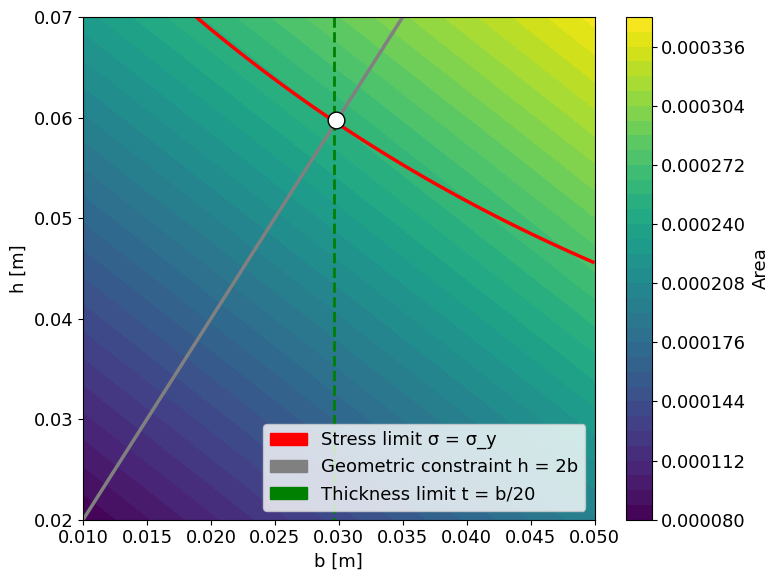

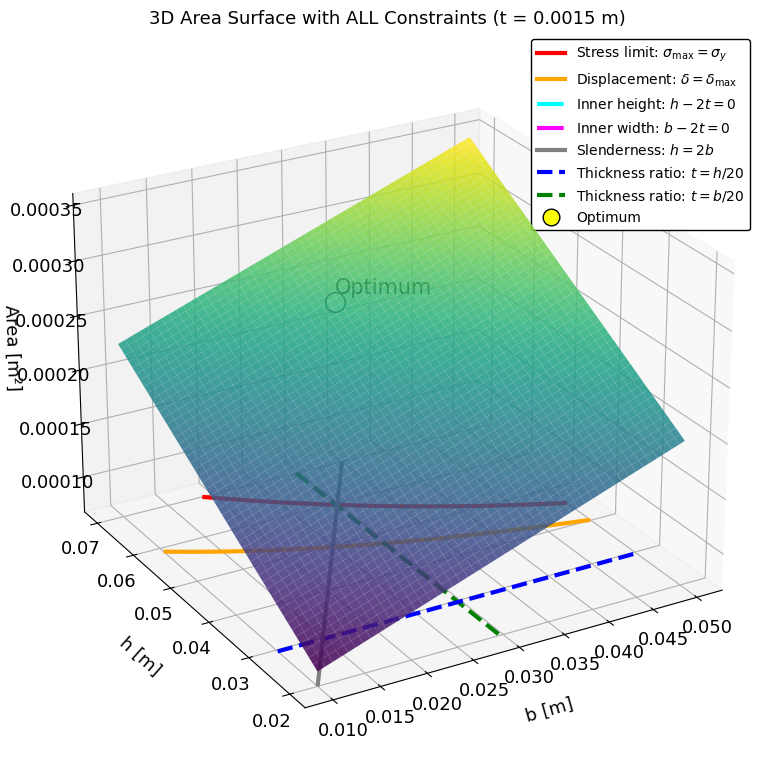

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds, NonlinearConstraint
# -------------------------------------------
# CLEAN + FOCUSED 2D FEASIBLE REGION PLOT
# -------------------------------------------

# ----------------------------------------------------------
# Build objective + ALL constraint fields on (b,h) grid
# ----------------------------------------------------------
A_map     = np.zeros_like(BB)

g1_stress = np.zeros_like(BB)   # 1 - sigma/sigma_y
g2_disp   = np.zeros_like(BB)   # 1 - delta/delta_max
g3_hw     = np.zeros_like(BB)   # h - 2t
g4_bw     = np.zeros_like(BB)   # b - 2t
g5_geom   = np.zeros_like(BB)   # h - 2b
g6_ratioH = np.zeros_like(BB)   # h/20 - t
g7_ratioB = np.zeros_like(BB)   # b/20 - t

for i in range(BB.shape[0]):
    for j in range(BB.shape[1]):
        b_ij = BB[i, j]
        h_ij = HH[i, j]
        xij  = np.array([b_ij, h_ij, t_slice])

        sigma, delta, A, I = beam_response(xij)

        A_map[i, j]     = A
        g1_stress[i, j] = 1.0 - sigma / sigma_y
        g2_disp[i, j]   = 1.0 - delta / delta_max
        g3_hw[i, j]     = h_ij - 2.0 * t_slice
        g4_bw[i, j]     = b_ij - 2.0 * t_slice
        g5_geom[i, j]   = h_ij - 2.0 * b_ij
        g6_ratioH[i, j] = h_ij / 20.0 - t_slice
        g7_ratioB[i, j] = b_ij / 20.0 - t_slice

plt.rcParams.update({
    'font.size': 13,          # default text size
    'axes.titlesize': 13,     # title size
    'axes.labelsize': 13,     # x/y label size
    'xtick.labelsize': 13,    # x tick labels
    'ytick.labelsize': 13,    # y tick labels
    'legend.fontsize': 13,    # legend text
    'figure.titlesize': 13    # figure title
})

t_slice = float(res1.x[2])

b_vals = np.linspace(0.01, 0.05, 300) 
h_vals = np.linspace(0.02, 0.07, 300)
BB, HH = np.meshgrid(b_vals, h_vals)

A_map = np.zeros_like(BB)

# Constraint fields
g1_stress = np.zeros_like(BB)
g5_geom   = np.zeros_like(BB)
g7_ratioB = np.zeros_like(BB)

for i in range(BB.shape[0]):
    for j in range(BB.shape[1]):
        xij = np.array([BB[i, j], HH[i, j], t_slice])
        sigma, delta, A, I = beam_response(xij)

        A_map[i, j] = A
        g1_stress[i,j] = 1 - sigma/sigma_y
        g5_geom[i,j]   = HH[i,j] - 2*BB[i,j]
        g7_ratioB[i,j] = BB[i,j]/20 - t_slice


plt.figure(figsize=(8,6))

# Background objective contours
cs = plt.contourf(BB, HH, A_map, 40, cmap="viridis")
plt.colorbar(cs, label="Area")

# IMPORTANT CONSTRAINTS
plt.contour(BB, HH, g1_stress, levels=[0], colors='red', linewidths=2.5)
plt.contour(BB, HH, g5_geom,   levels=[0], colors='grey', linewidths=2.5)
plt.contour(BB, HH, g7_ratioB, levels=[0], colors='green', linewidths=2.0, linestyles='dashed')

# Mark optimum
plt.plot(res1.x[0], res1.x[1], 'wo', markersize=12, markeredgecolor='black')

plt.xlabel("b [m]")
plt.ylabel("h [m]")


# Legend
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='red',   label='Stress limit σ = σ_y'),
    mpatches.Patch(color='grey', label='Geometric constraint h = 2b'),
    mpatches.Patch(color='green', label='Thickness limit t = b/20')
]
plt.legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.show()
# -------------------------------------------
# Compute A_opt BEFORE plotting 3D
# -------------------------------------------
A_opt, _ = section_properties(res1.x)

# ==========================================================
# IMPROVED 3D DESIGN SPACE WITH ALL CONSTRAINTS
# ==========================================================

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Objective surface (Area)
surf = ax.plot_surface(
    BB, HH, A_map,
    cmap="viridis",
    edgecolor="none",
    alpha=0.85
)

# ----------------------------------------------------------
# Make z-limits clean + padded for readability
# ----------------------------------------------------------
zmin, zmax = np.min(A_map), np.max(A_map)
pad = 0.05 * (zmax - zmin)
ax.set_zlim(zmin - pad, zmax + pad)

# ----------------------------------------------------------
# DRAW ALL CONSTRAINT LIMITS IN 3D
# (walls extruded vertically for visual clarity)
# ----------------------------------------------------------

# Stress limit g1=0
ax.contour(
    BB, HH, g1_stress,
    levels=[0],
    colors='red',
    linewidths=3,
    linestyles='solid',
    zdir='z',
    offset=zmin - pad
)

# Displacement limit g2=0 (if included)
ax.contour(
    BB, HH, g2_disp,
    levels=[0],
    colors='orange',
    linewidths=3,
    linestyles='solid',
    zdir='z',
    offset=zmin - pad
)

# Geometric constraint h = 2b
ax.contour(
    BB, HH, g5_geom,
    levels=[0],
    colors='grey',
    linewidths=3,
    linestyles='solid',
    zdir='z',
    offset=zmin - pad
)

# Hollow constraint b - 2t = 0
ax.contour(
    BB, HH, g4_bw,
    levels=[0],
    colors='magenta',
    linewidths=3,
    linestyles='dashdot',
    zdir='z',
    offset=zmin - pad
)

# Hollow constraint h - 2t = 0
ax.contour(
    BB, HH, g3_hw,
    levels=[0],
    colors='cyan',
    linewidths=3,
    linestyles='dashdot',
    zdir='z',
    offset=zmin - pad
)

# Thickness ratios
ax.contour(
    BB, HH, g6_ratioH,
    levels=[0],
    colors='blue',
    linewidths=3,
    linestyles='dashed',
    zdir='z',
    offset=zmin - pad
)
ax.contour(
    BB, HH, g7_ratioB,
    levels=[0],
    colors='green',
    linewidths=3,
    linestyles='dashed',
    zdir='z',
    offset=zmin - pad
)

# ----------------------------------------------------------
# Mark optimum clearly
# ----------------------------------------------------------
ax.scatter(
    res1.x[0], res1.x[1], A_opt,
    c='white', edgecolor='black',
    s=200, marker='o'
)
ax.text(
    res1.x[0], res1.x[1], A_opt + pad*0.5,
    "Optimum", color='black', fontsize=15
)

# ----------------------------------------------------------
# Labels and title
# ----------------------------------------------------------
ax.set_xlabel("b [m]", labelpad=12)
ax.set_ylabel("h [m]", labelpad=12)
ax.set_zlabel("Area [m²]", labelpad=10)
ax.set_title(f"3D Area Surface with ALL Constraints (t = {t_slice:.4f} m)")

ax.view_init(elev=25, azim=240)
# ----------------------------------------------------------
# LEGEND FOR 3D CONSTRAINTS — BOXED + LATEX
# ----------------------------------------------------------
import matplotlib.lines as mlines
from matplotlib.patches import Patch

legend_handles = [
    mlines.Line2D([], [], color='red', linewidth=3,
                  label=r'Stress limit: $\sigma_{\max} = \sigma_{y}$'),
    
    mlines.Line2D([], [], color='orange', linewidth=3,
                  label=r'Displacement: $\delta = \delta_{\max}$'),
    
    mlines.Line2D([], [], color='cyan', linewidth=3, linestyle='dashdot',
                  label=r'Inner height: $h - 2t = 0$'),
    
    mlines.Line2D([], [], color='magenta', linewidth=3, linestyle='dashdot',
                  label=r'Inner width: $b - 2t = 0$'),
    
    mlines.Line2D([], [], color='grey', linewidth=3,
                  label=r'Slenderness: $h = 2b$'),
    
    mlines.Line2D([], [], color='blue', linewidth=3, linestyle='dashed',
                  label=r'Thickness ratio: $t = h/20$'),
    
    mlines.Line2D([], [], color='green', linewidth=3, linestyle='dashed',
                  label=r'Thickness ratio: $t = b/20$'),
    
    mlines.Line2D([], [], color='yellow', marker='o', markersize=12,
                  markeredgecolor='black', linestyle='None',
                  label=r'Optimum')
]

# Draw boxed legend
legend = ax.legend(handles=legend_handles,
                   loc='upper right',
                   fontsize=10,
                   framealpha=1.0,      # solid box
                   facecolor='white',   # white background
                   edgecolor='black',   # black border
                   frameon=True)

# Make the legend text black even if background is white
for text in legend.get_texts():
    text.set_color('black')

plt.tight_layout()
plt.show()


Convergence plots - 2D constraint slices

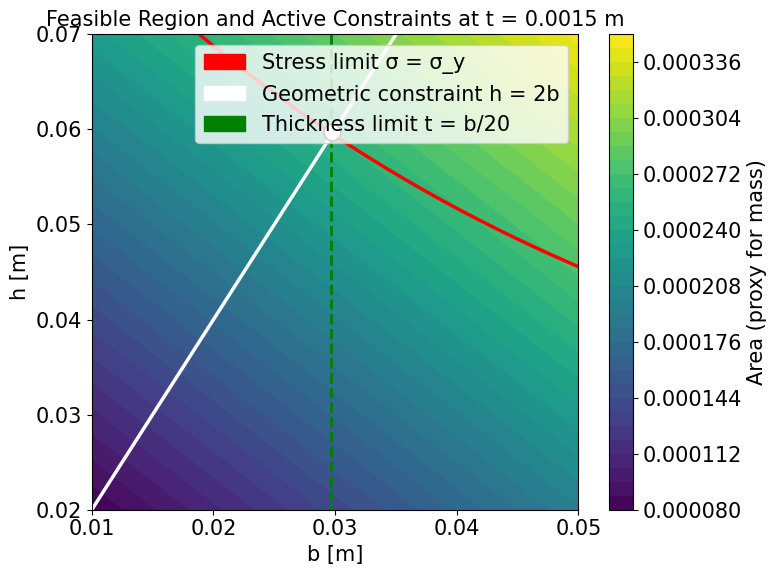

NameError: name 'A_opt' is not defined

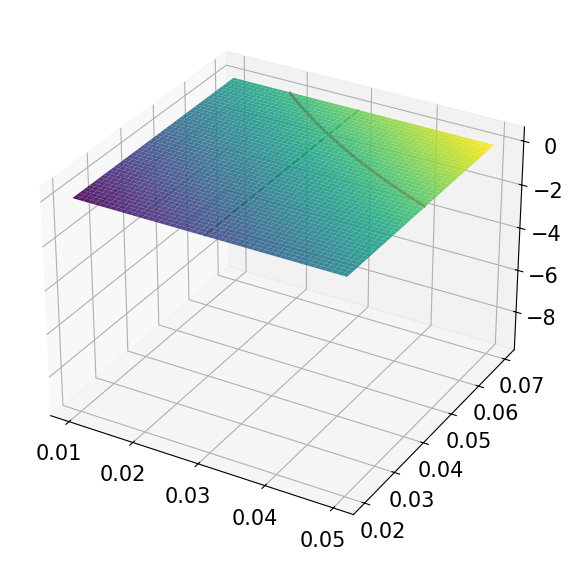

In [ ]:
# -------------------------------------------
# CLEAN + FOCUSED 2D FEASIBLE REGION PLOT
# -------------------------------------------
plt.rcParams.update({
    'font.size': 15,          # default text size
    'axes.titlesize': 15,     # title size
    'axes.labelsize': 15,     # x/y label size
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 15,    # legend text
    'figure.titlesize': 15    # figure title
})


t_slice = float(res1.x[2])

b_vals = np.linspace(0.01, 0.05, 300) 
h_vals = np.linspace(0.02, 0.07, 300)
BB, HH = np.meshgrid(b_vals, h_vals)

A_map = np.zeros_like(BB)

# Constraint fields
g1_stress = np.zeros_like(BB)
g5_geom   = np.zeros_like(BB)
g7_ratioB = np.zeros_like(BB)

for i in range(BB.shape[0]):
    for j in range(BB.shape[1]):
        xij = np.array([BB[i, j], HH[i, j], t_slice])
        sigma, delta, A, I = beam_response(xij)

        A_map[i, j] = A
        g1_stress[i,j] = 1 - sigma/sigma_y
        g5_geom[i,j]   = HH[i,j] - 2*BB[i,j]
        g7_ratioB[i,j] = BB[i,j]/20 - t_slice


plt.figure(figsize=(8,6))

# Background objective contours
cs = plt.contourf(BB, HH, A_map, 40, cmap="viridis")
plt.colorbar(cs, label="Area (proxy for mass)")

# IMPORTANT CONSTRAINTS
plt.contour(BB, HH, g1_stress, levels=[0], colors='red', linewidths=2.5)
plt.contour(BB, HH, g5_geom,   levels=[0], colors='white', linewidths=2.5)
plt.contour(BB, HH, g7_ratioB, levels=[0], colors='green', linewidths=2.0, linestyles='dashed')

# Mark optimum
plt.plot(res1.x[0], res1.x[1], 'wo', markersize=12, markeredgecolor='black')

plt.xlabel("b [m]")
plt.ylabel("h [m]")
plt.title(f"Feasible Region and Active Constraints at t = {t_slice:.4f} m")

# Legend
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='red',   label='Stress limit σ = σ_y'),
    mpatches.Patch(color='white', label='Geometric constraint h = 2b'),
    mpatches.Patch(color='green', label='Thickness limit t = b/20')
]
plt.legend(handles=handles, loc='upper right')

plt.tight_layout()
plt.show()


# -------------------------------------------
# CLEAN 3D DESIGN SURFACE PLOT
# -------------------------------------------

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Smooth surface
surf = ax.plot_surface(
    BB, HH, A_map,
    cmap="viridis", 
    edgecolor="none", 
    alpha=0.9
)

# Stress boundary ON the surface
ax.contour(
    BB, HH, A_map,
    levels=[np.min(A_map) + 1e-6], # dummy
    colors='none'
)
ax.contour(
    BB, HH, g1_stress,
    levels=[0], 
    colors='red', 
    linewidths=2
)

# Geometric boundary h = 2b
ax.contour(
    BB, HH, g5_geom,
    levels=[0],
    colors='white',
    linewidths=2
)

# Near-active thickness constraint
ax.contour(
    BB, HH, g7_ratioB,
    levels=[0],
    colors='green',
    linestyles='dashed',
    linewidths=1.5
)

# Mark optimum
ax.scatter(
    res1.x[0], 
    res1.x[1], 
    A_opt,
    c='white',
    s=80,
    edgecolor='black',
    label='Optimum'
)

ax.set_xlabel("b [m]")
ax.set_ylabel("h [m]")
ax.set_zlabel("Area [m²]", labelpad=8)
ax.set_zlim(A_map.min(), A_map.max())
ax.set_title(f"3D Objective Surface with Active Constraints (t = {t_slice:.4f})")
ax.view_init(elev=25, azim=230)

plt.tight_layout()
plt.show()


t_min = 0.041291 t_max = 0.164233
Using stress correction (|bias| + MAE) = 37.129999999999995 MPa
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.041291
            Iterations: 3
            Function evaluations: 6
            Gradient evaluations: 3

===== Q3.2 A (constant) =====
x* = [0.041291]
Mean thickness A = 0.04129 m, σ_max(A, corrected) = 220.19 MPa


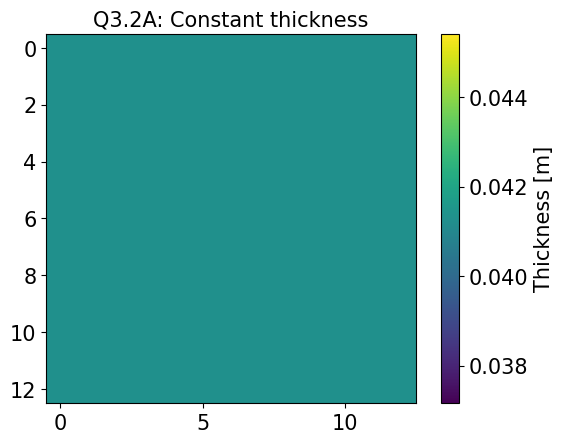

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.04129100000000001
            Iterations: 3
            Function evaluations: 15
            Gradient evaluations: 3

===== Q3.2 B (corner) =====
x* = [0.041291 0.041291 0.041291 0.041291]
Mean thickness B = 0.04129 m, σ_max(B, corrected) = 220.19 MPa


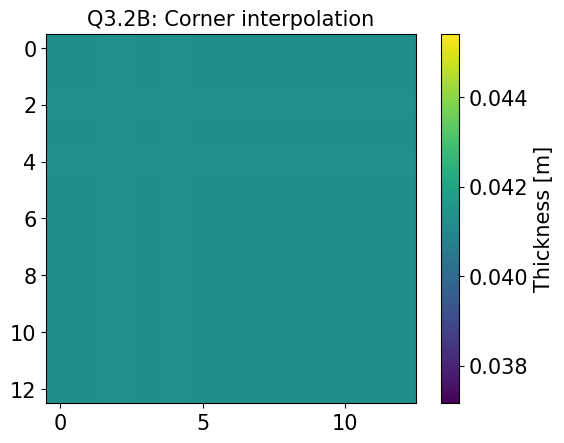

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import RectBivariateSpline
import tensorflow as tf
plt.rcParams.update({
    'font.size': 15,          # default text size
    'axes.titlesize': 15,     # title size
    'axes.labelsize': 15,     # x/y label size
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 15,    # legend text
    'figure.titlesize': 15    # figure title
})

# ---------------------------------------------------------
# Global settings
# ---------------------------------------------------------
sigma_y = 250.0      # MPa (yield limit)
corr    = 1.065      # global scale correction you already used
rows = cols = 13

# Thickness bounds from dataset
t_min = float(X.min())
t_max = float(X.max())
print("t_min =", t_min, "t_max =", t_max)

# Grid for interpolation
u_full = np.linspace(0.0, 1.0, rows)
v_full = np.linspace(0.0, 1.0, cols)

# ---------------------------------------------------------
# Surrogate error statistics (from your tests)
# ---------------------------------------------------------
bias = -21.18         # MPa (mean underprediction)
MAE = 15.95

CORRECTION = abs(bias) + MAE  
print("Using stress correction (|bias| + MAE) =", CORRECTION, "MPa")

CORRECTION_TF = tf.constant(CORRECTION, dtype=tf.float32)

# ---------------------------------------------------------
# TensorFlow scaler parameters for surrogate_sigma_map_tf
# ---------------------------------------------------------
mu_X    = tf.constant(scaler_X.mean_,  dtype=tf.float32)
scale_X = tf.constant(scaler_X.scale_, dtype=tf.float32)
mu_Y    = tf.constant(scaler_Y.mean_,  dtype=tf.float32)
scale_Y = tf.constant(scaler_Y.scale_, dtype=tf.float32)


# =========================================================
#  Surrogate: NumPy version (for SLSQP: A–C)
# =========================================================
def surrogate_sigma_map(th):
    """
    NumPy wrapper around your trained CNN.
    Input:  th (13x13) array of thickness
    Output: sigma_map (13x13) array of stress [MPa] with global corr
    """
    th_flat = th.reshape(1, -1)
    x_scaled_flat = scaler_X.transform(th_flat)
    x_scaled = x_scaled_flat.reshape(1, rows, cols, 1)

    y_scaled = model.predict(x_scaled, verbose=0)
    y_scaled_flat = y_scaled.reshape(1, -1)
    y_unscaled = scaler_Y.inverse_transform(y_scaled_flat)

    sigma_map = y_unscaled.reshape(rows, cols)
    return corr * sigma_map   # apply global scaling


# =========================================================
#  Surrogate: TensorFlow version (for Adam: D)
# =========================================================
def surrogate_sigma_map_tf(th_tf):
    """
    TF wrapper around the same CNN.
    Input:  th_tf (13x13) tensor
    Output: sigma_map (13x13) tensor [MPa] with global corr
    """
    th_flat = tf.reshape(th_tf, (1, -1))
    x_scaled_flat = (th_flat - mu_X) / scale_X
    x_scaled = tf.reshape(x_scaled_flat, (1, rows, cols, 1))

    y_scaled = model(x_scaled, training=False)
    y_scaled_flat = tf.reshape(y_scaled, (1, -1))
    y_unscaled = y_scaled_flat * scale_Y + mu_Y

    sigma_map = tf.reshape(y_unscaled, (rows, cols))
    return corr * sigma_map   # same scaling


# =========================================================
#  Spatial constraint used by SLSQP (A–C)
#  g(x) >= 0  <=>  min_ij [sigma_y - (sigma_ij + CORRECTION)] >= 0
# =========================================================
def spatial_constraint(th):
    sigma_map = surrogate_sigma_map(th)
    sigma_corr = sigma_map + CORRECTION   # bias + RMSE safety
    return np.min(sigma_y - sigma_corr)


# =========================================================
#  Helper: run SLSQP
# =========================================================
def run_slsqp(obj, constr, x0, bounds, label, maxiter=200):
    cons = {'type': 'ineq', 'fun': constr}
    res = minimize(obj, x0, method='SLSQP',
                   bounds=bounds,
                   constraints=[cons],
                   options={'maxiter': maxiter, 'disp': True})
    print(f"\n===== {label} =====")
    print("x* =", res.x)
    return res


# =========================================================
#  Q3.2A — Constant thickness
# =========================================================
def plate_A(x):
    return np.full((rows, cols), x[0])

def obj_A(x):
    return x[0]  # minimise thickness

def constr_A(x):
    th = plate_A(x)
    return spatial_constraint(th)

x0_A = np.array([0.08])
bounds_A = [(t_min, t_max)]

res_A = run_slsqp(obj_A, constr_A, x0_A, bounds_A, "Q3.2 A (constant)")
thA = plate_A(res_A.x)

sigmaA = surrogate_sigma_map(thA) + CORRECTION
print(f"Mean thickness A = {thA.mean():.5f} m, "
      f"σ_max(A, corrected) = {sigmaA.max():.2f} MPa")

plt.imshow(thA, cmap='viridis')
plt.colorbar(label="Thickness [m]")
plt.title("Q3.2A: Constant thickness")
plt.show()


# =========================================================
#  Q3.2B — Corner interpolation (4 DOF)
# =========================================================
def plate_B(x):
    TL, TR, BL, BR = x
    top    = (1 - v_full)*TL + v_full*TR
    bottom = (1 - v_full)*BL + v_full*BR
    u = u_full.reshape(-1,1)
    return (1 - u)*top + u*bottom

def obj_B(x):
    return plate_B(x).mean()

def constr_B(x):
    return spatial_constraint(plate_B(x))

x0_B = np.full(4, 0.08)
bounds_B = [(t_min, t_max)] * 4

res_B = run_slsqp(obj_B, constr_B, x0_B, bounds_B, "Q3.2 B (corner)")
thB = plate_B(res_B.x)
sigmaB = surrogate_sigma_map(thB) + CORRECTION

print(f"Mean thickness B = {thB.mean():.5f} m, "
      f"σ_max(B, corrected) = {sigmaB.max():.2f} MPa")

plt.imshow(thB, cmap='viridis')
plt.colorbar(label="Thickness [m]")
plt.title("Q3.2B: Corner interpolation")
plt.show()


# =========================================================
#  Q3.2C — 5×5 grid (25 DOF)
# =========================================================
u5 = np.linspace(0,1,5)
v5 = np.linspace(0,1,5)

def plate_C(x):
    T = np.array(x).reshape(5,5)
    spl = RectBivariateSpline(u5, v5, T)
    return spl(u_full, v_full)

def obj_C(x):
    return plate_C(x).mean()

def constr_C(x):
    return spatial_constraint(plate_C(x))

x0_C = np.full(25, 0.08)
bounds_C = [(t_min, t_max)] * 25

res_C = run_slsqp(obj_C, constr_C, x0_C, bounds_C, "Q3.2 C (5×5 grid)", maxiter=300)
thC = plate_C(res_C.x)
sigmaC = surrogate_sigma_map(thC) + CORRECTION

print(f"Mean thickness C = {thC.mean():.5f} m, "
      f"σ_max(C, corrected) = {sigmaC.max():.2f} MPa")

plt.imshow(thC, cmap='viridis')
plt.colorbar(label="Thickness [m]")
plt.title("Q3.2C: 5×5 grid optimum")
plt.show()
T_raw = np.array(res_C.x).reshape(5,5)
plt.imshow(T_raw, cmap="viridis")
plt.colorbar(label="5×5 Raw DOFs")
plt.title("Raw 5×5 Design Variables (Before Spline Interpolation)")
plt.show()


# =========================================================
#  Q3.2D — Full 13×13 thickness with Adam
# =========================================================
lr = 0.02
iters = 500
lambda_strict = 2_000.0

xD = tf.Variable(np.full((rows,cols), 0.08, dtype=np.float32))
opt = tf.keras.optimizers.Adam(learning_rate=lr)

def obj_D_tf():
    th = xD
    mass = tf.reduce_mean(th)
    sigma_map = surrogate_sigma_map_tf(th) + CORRECTION_TF
    penalty = tf.reduce_sum(tf.nn.relu(sigma_map - sigma_y)**2)
    return mass + lambda_strict * penalty

for k in range(iters):
    with tf.GradientTape() as tape:
        loss = obj_D_tf()
    grads = tape.gradient(loss, [xD])
    opt.apply_gradients(zip(grads, [xD]))
    xD.assign(tf.clip_by_value(xD, t_min, t_max))

    if k % 50 == 0:
        print(f"iter {k}: obj={float(loss):.6f}")

thD = xD.numpy()
sigmaD = surrogate_sigma_map(thD) + CORRECTION

print("\n===== Q3.2 D (full 13×13, Adam) =====")
print(f"Mean thickness D = {thD.mean():.5f} m, "
      f"σ_max(D, corrected) = {sigmaD.max():.2f} MPa")

plt.imshow(thD, cmap='viridis')
plt.colorbar(label="Thickness [m]")
plt.title("Q3.2D: Full-variable optimum (Adam)")
plt.show()
